In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp
from functions import build_rv_curve

In [3]:
#some constants
G = 6.67430*(10**(-11)) #SI
Msun = 2*(10**30) #SI
au2m = 1.496e+11
Me = 5.972*(10**24)
c = 2.998e+8 #speed of light in m/s
halpha_rest = 6562.8 #angstrom

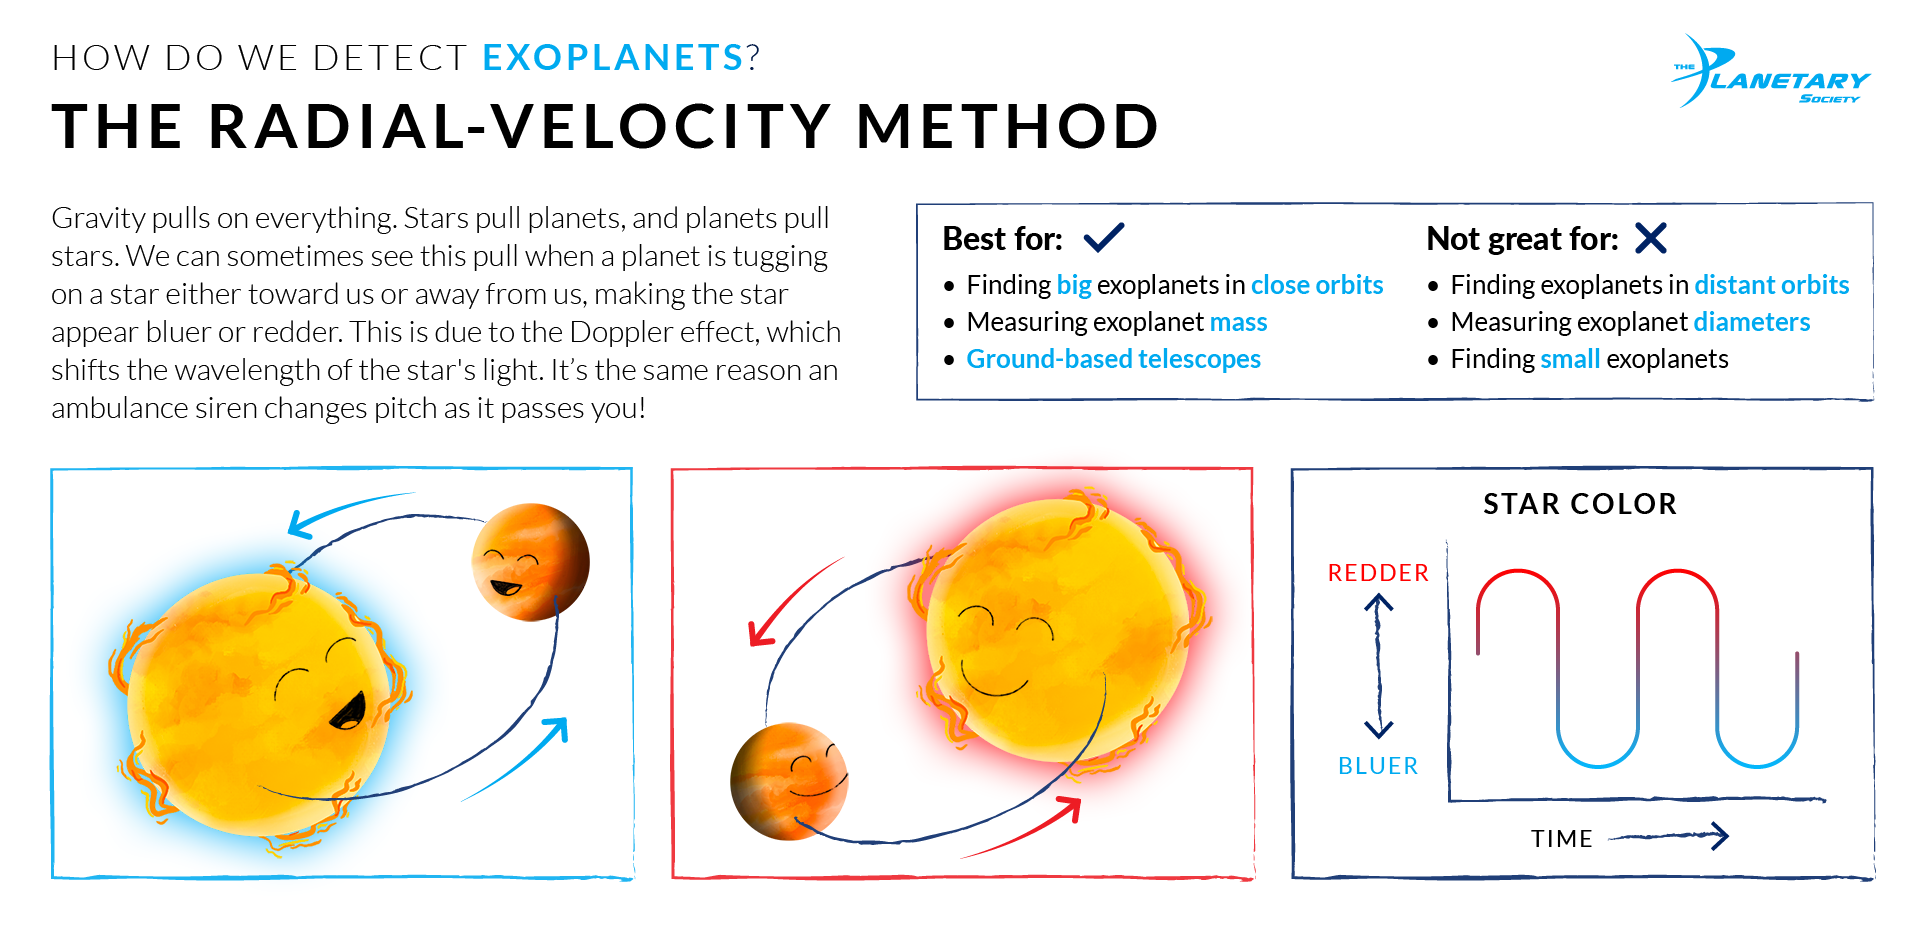

The Doppler effect "is the change in the frequency of a wave in relation to an observer who is moving relative to the source of the wave." It applies to both sound and light. One classic example is that of a passing car or train: The pitch of the vehicle is higher as it approaches you, and to a lower pitch as it passes and moves away from you. I won't go into it too much here but here is a good high-level explanation if you want to read more (https://imagine.gsfc.nasa.gov/features/yba/M31_velocity/spectrum/doppler_more.html). For our purposes we just need to know that as a a star moves towards us, the light it emits is shifted towards bluer colors (shorter wavelengths; higher frequencies). As the star moves away its light is shifted towards redder colors (longer wavelengths; lower frequencies). 

To determine how much the light has shifted, we can look at emission and/or absorption lines in the star's spectrum. These correspond to atomic transitions whose energies can be measured very precisely. Take for example the Balmer series which corresponds to electronic transitions from the 1st excited state of Hydrogen (n = 2) to a higher state via absorption of a photon or vice versa via the emission of a photon hence the names absorption lines vs emission lines. Absorption lines will show up as a decrease in light relative to the continuum of a star b/c light is being absorbed. The converse is true for emission lines. The two figures below illustrate the Balmer series and how these show up as an absorption line in a spectrum.


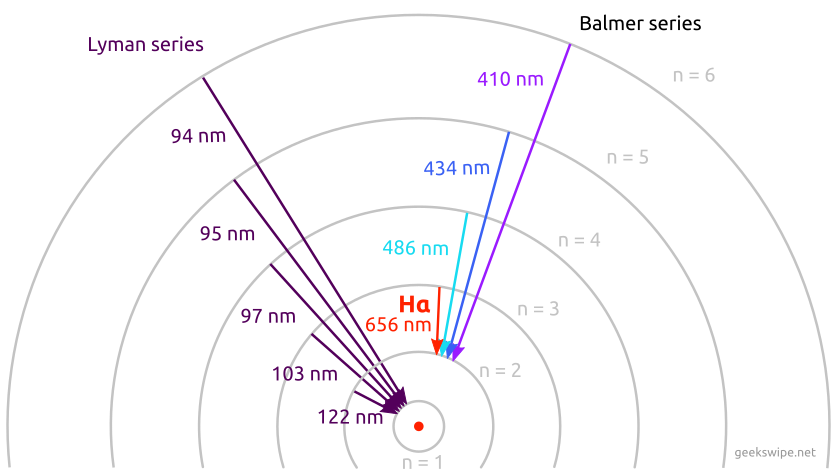


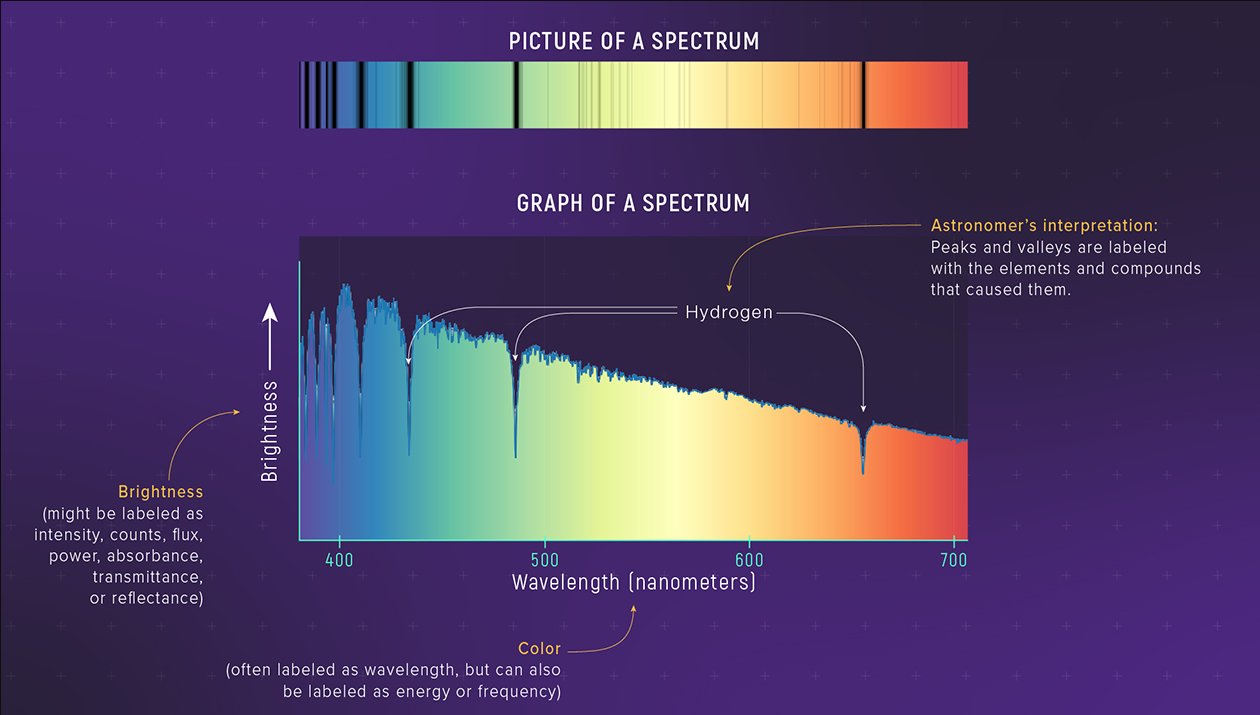

Let's take a closer look at the H-alpha transition, which refers is the transition between the first (n=2) and second excited states (n=3) of the hydrogen atom. The energy associated with this transition corresponds to a photon wavelength of $656.28$ nm. This value is the so-called rest wavelength of the transition, $\lambda_{rest}$, i.e., what you measure in the laboratory when you are stationary relative to the H atom(s). The uncertainty on $\lambda_{rest}$ for H$\alpha$ according to NIST is $\pm 0.000003$, so we can treat it as exact. 

The observed wavelength, $\lambda_{obs}$, of a line in the atmopshere of a moving star is given by 

$$\Large \lambda_{obs} = \lambda_{rest}\sqrt{\frac{c + v_r}{c - v_r}}$$

or

$$\Large \lambda_{obs} = \lambda_{rest}\sqrt{\frac{1 + v_r/c}{1 - v_r/c}} \; \; \; \mathrm{(1)}$$.

This is the full relavistic solution for the Doppler effect of light. See https://youtu.be/0EOWEMZHZpI?si=Hnsp7NiaGHay-zAp for a good derivation, if you are curious. Note, in the video the signs are flipped in the equation above. I.e., the speaker gives

$$\Large \lambda_{obs} = \lambda_{rest}\sqrt{\frac{c - v_r}{c + v_r}}$$.

Both are valid. The difference arises because we are defining a positive radial velocity to be in opposite directions. Using Eq 1, discuss with your group what direction I am defining as positive radial velocities. Is it towards or away from the observer? Also, mathematically, there is nothing stopping us from putting in numbers for $v_r$ that give a negative number for the arguement of a square root (remember $\sqrt{-1} \equiv i$). If we use physically \it{allowed} numbers, however, we will never get an imaginary number. Why? What do I mean by 'physically allowed'?

Hint: remember that when an object is moving away from the observer, any light it emits is redshifted meaning the observed wavelenght of light increases relative to the rest wavelength.


If we are dealing with objects that are moving much slower than the speed of light (as will be with most), we simplify Eq. 1 to just

$$\Large \lambda_{obs} \simeq \lambda_{rest} \left(1 + \frac{v_r}{c}\right) \; \; \; (2)$$

For fun: where does Eq. 2 come from? 

Hints: 
- think back to calc II 
- $\Large \frac{d}{dx}\sqrt{\frac{1+x}{1-x}}$ evaluated at 0 = 1


The radial velocity signal of Earth is $\sim 0.08$ m/s. How much do Eq. 1 and 2 differ?

How about for the more extreme case of two Sun-like stars orbiting one another with a semi-major axis of 0.1 AU? This gives an RV signal of $\sim 30,000$ m/s.

Now that we have a relationship between observed wavelength and radial velocity, we can start building RV curves. The semi-amplitude of the radial velocity curve, $K$, is given by 

$$\Large K = \left(\frac{M_p}{M_{star}}\right)\sqrt{\frac{GM_{star}}{a}} \sin i \; \; \; (3)$$.

This is also the average between the minimum and maximum radial velocities. Notice there is no dependence on orbital eccentricity. I have included a figure below as a reminder of how eccentricity is defined. 

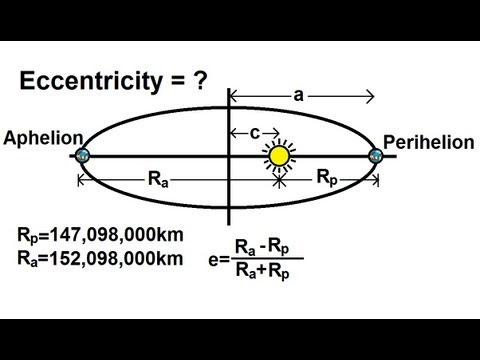


For a circular orbit (e = 0), $K$ is just the amplitude of the sine wave. For the same planet mass and same semi-major axis (a), an eccentric orbit (e > 0) will have higher max and min radial velocities than a circular orbit, but their semi-amplitudes will be the same. See below for a 1 Earth mass planet with a = 1 AU on a circular orbit (left) compared with a highly eccentric orbit (right) of e = 0.9.

Text(0.5, 0, 'Orbital Phase')

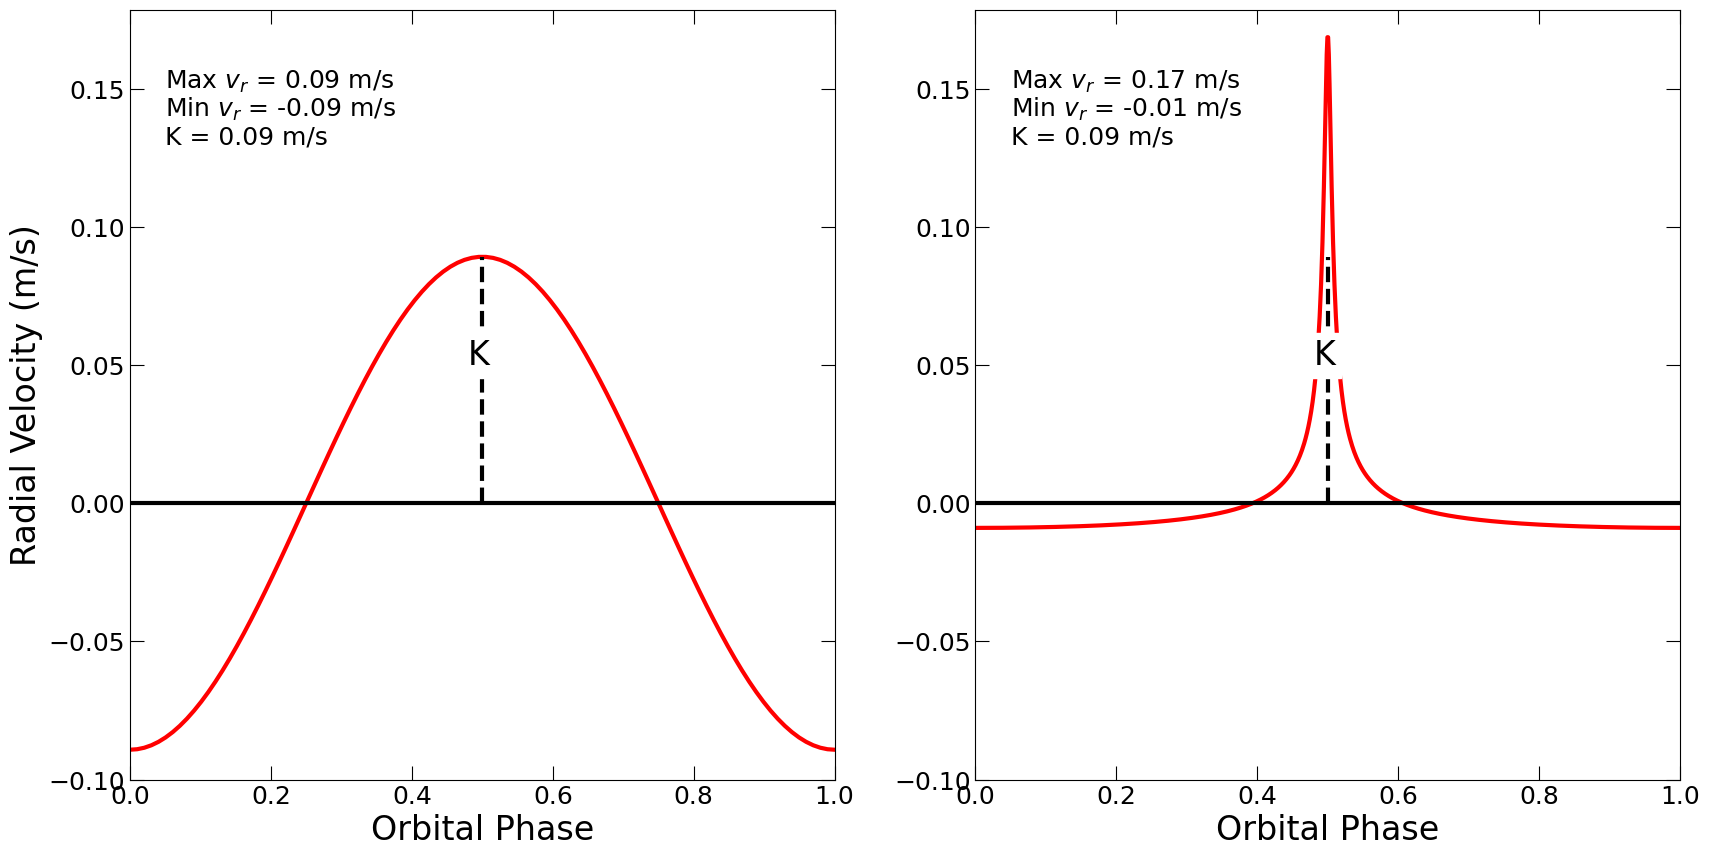

In [11]:
fig, ax = plt.subplots(1,2, figsize = (20,10))

phase, vel, E, ha_obs, K = build_rv_curve(Mp = 1.0, a = 1.0, numpts = 100)
ax[0].plot(phase, -vel, 'r-', lw = 3)
ax[0].axhline(0.0, color = 'k', ls = '-', lw = 3)
ax[0].tick_params(which = 'both', top = True, right = True, length = 10, direction = 'in', labelsize = 18)
ax[0].text(0.05, 0.15, r'Max $v_r$ = ' + str(round(max(-vel)[0], 2)) + ' m/s', fontsize = 18)
ax[0].text(0.05, 0.14, r'Min $v_r$ = ' + str(round(min(-vel)[0], 2)) + ' m/s', fontsize = 18)
ax[0].text(0.05, 0.13, r'K = ' + str(round(K, 2)) + ' m/s', fontsize = 18)
ax[0].plot([0.5, 0.5], [0, K], 'k--', lw = 3)
ax[0].text(0.48, 0.05, 'K', fontsize = 24, backgroundcolor = 'w')




phase, vel, E, ha_obs, K = build_rv_curve(Mp = 1.0, a = 1.0, e = 0.9, numpts = 1000)
ax[1].plot(phase, -vel, 'r-', lw = 3)
ax[1].axhline(0.0, color = 'k', ls = '-', lw = 3)
ax[1].tick_params(which = 'both', top = True, right = True, length = 10, direction = 'in', labelsize = 18)
ax[1].text(0.05, 0.15, r'Max $v_r$ = ' + str(round(max(-vel)[0], 2)) + ' m/s', fontsize = 18)
ax[1].text(0.05, 0.14, r'Min $v_r$ = ' + str(round(min(-vel)[0], 2)) + ' m/s', fontsize = 18)
ax[1].text(0.05, 0.13, r'K = ' + str(round(K, 2)) + ' m/s', fontsize = 18)
ax[1].plot([0.5, 0.5], [0, K], 'k--', lw = 3)
ax[1].text(0.48, 0.05, 'K', fontsize = 24, backgroundcolor = 'w')



ax[0].set_ylim(-0.1, max(-vel) + 0.01)
ax[0].set_xlim(0.0, 1.0)

ax[1].set_ylim(-0.1, max(-vel) + 0.01)
ax[1].set_xlim(0.0, 1.0)


ax[0].set_ylabel('Radial Velocity (m/s)', fontsize = 24)
ax[0].set_xlabel('Orbital Phase', fontsize = 24)
ax[1].set_xlabel('Orbital Phase', fontsize = 24)


The semi-amplitude of the radial velocity curve is really the fundamental parameter of this technique. If the mass of the star and inclination angle of the planet are known, then we can calculate planet mass. If the inclination angle is unknown then we can only calculate the minimum mass of the planet. Why?

### Let's build some RV curves!

The 'build_rv_curve' function below builds an RV curve for a planet of mass Mp (in Earth masses) around a Sun-mass star on an orbit defined by the following parameters:

- i = the inclination angle of the orbit relative to the observer (in RADIANS). An edge on orbit is $i = \pi / 2$ and a face on orbit is $i = 0$.
- e = orbital eccentricity. Eccentricity measures how much how much the orbit deviates from circular. As such, a circular orbit has e = 0. e$\geq 1$ represent unbound orbits
- a = the semi-major axis


I want you to explore how planet mass, semi-major axis, eccentricity, and inclination angle change the amplitude and shape of the radial velocity signal. It is currently set up to simulate an object with $M_p = 0.5 M_\odot$, so not really a planet. This set-up represents something called a single-lined binary. I did this so you can see the orbit of the star. When you start simulating planet sized objects, the orbit of the star will become unresolvable. Run the animation as is to start and try to figure out what direction you observing from.

These animations take a minute to build, so I have included a few pre-generated ones in the 'pre-loaded animations' folder. Discuss with your group how the inclination angle changes the amplitude of the RV curve and how eccentricity changes the shape + minimum and maximum values. 

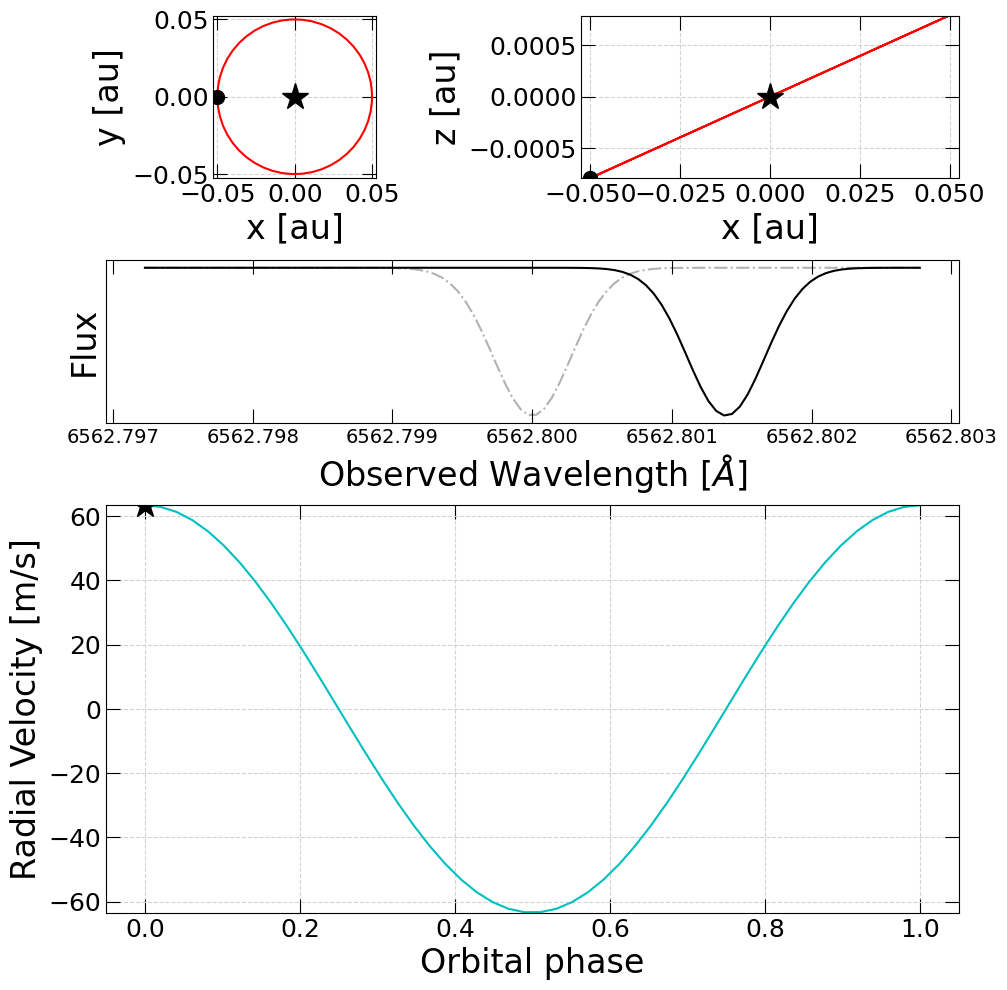

In [101]:
#------------------------------------------User inputs-----------------------------------------------------------------#
Mp = 0.5*317.828133 #planet mass in Earth masses
a = 0.05 #Semi-major axis in AU
e = 0.0 #eccentricity from 0-1
inc = 0.99*np.pi/2.0 #inclination angle -- varies from 0 to pi/2 (0 to 90 degrees)

#-----------------------------------------------------------------------------------------------------------------------#

b = a*np.sqrt(1.0 - e**2)
focci = e*a

phase, vel, E, ha_obs, K = build_rv_curve(Mp = Mp, a = a, i = inc, e = e, numpts = 50)
x = (a*np.cos(E) - focci)
y = b*np.sin(E)

astar = a*(Mp*Me)/Msun
bstar = astar*np.sqrt(1.0 - e**2)
xstar = (astar*np.cos(E + np.pi) + e*astar)
ystar =  bstar*np.sin(E + np.pi)


xmax = max([max(abs(xstar)), max(abs(x))])
xmax = xmax + 0.05*xmax

ymax = max([max(abs(ystar)), max(abs(y))])
ymax = ymax + 0.05*ymax

pause = min(abs(vel))/abs(vel)
#pause = abs(x)


fig, hold = plt.subplots(1,1,figsize = (10,10))
hold.set_axis_off()

ax = plt.subplot2grid((4,2), loc = (0,0), colspan = 1, rowspan = 1)
ax4 = plt.subplot2grid((4,2), loc = (1,0), colspan = 2, rowspan = 1)
ax2 = plt.subplot2grid((4,2), loc = (0,1), colspan = 1, rowspan = 1)
ax3 = plt.subplot2grid((4,2), loc = (2,0), colspan = 2, rowspan = 2)

#ax.set_axis_off()

ax.plot(x*np.cos(inc - np.pi/2.0),y, 'r-')
ax.plot(xstar*np.cos(inc - np.pi/2.0), ystar, 'c-')

ax2.plot(xstar*np.cos(inc - np.pi/2.0), -xstar*np.sin(inc - np.pi/2.0), 'c-')
ax2.plot(x*np.cos(inc - np.pi/2.0), -x*np.sin(inc - np.pi/2.0), 'r-', alpha = 1.0)


ha_width = (max(ha_obs) - min(ha_obs))/10.0

ax.grid(color='lightgray',linestyle='--');
ax2.grid(color='lightgray',linestyle='--');
ax3.grid(color='lightgray',linestyle='--');


if xmax > ymax:
    ax.set_xlim(-xmax, xmax)
    ax.set_ylim(-xmax, xmax)
else:
    ax.set_xlim(-ymax, ymax)
    ax.set_ylim(-ymax, ymax)
    
ax.set_aspect('equal', 'box')
    

ax2.set_xlim((-xmax*np.cos(inc - np.pi/2.0))[0], (xmax*np.cos(inc - np.pi/2.0))[0])
ax2.set_ylim(
    min([min(-x*np.sin(inc - np.pi/2.0)), min(-xstar*np.sin(inc - np.pi/2.0))]),
         max([max(-x*np.sin(inc - np.pi/2.0)), max(-xstar*np.sin(inc - np.pi/2.0))]))
ax2.set_xlim(-xmax, xmax)

ax3.plot(phase, vel, 'c-', alpha = 1.0);
ax3.set_ylim(-max(abs(vel)), max(abs(vel)))

xhold = np.linspace(min(ha_obs)-5*ha_width, max(ha_obs) + 5*ha_width, 100)
ax4.plot(xhold, -sp.norm.pdf(xhold, loc = 0.0, scale = ha_width), 'r-.', alpha = 1.0)


ax.set_xlabel('x [au]', fontsize = 24)
ax.set_ylabel('y [au]', fontsize = 24)

ax2.set_xlabel('x [au]', fontsize = 24)
ax2.set_ylabel('z [au]', fontsize = 24)


ax3.set_ylabel('Radial Velocity [m/s]', fontsize = 24)
ax3.set_xlabel('Orbital phase', fontsize = 24)


ax.tick_params(which = 'both', top = True, right = True, direction = 'in', length = 10, labelsize = 18)
ax2.tick_params(which = 'both', top = True, right = True, direction = 'in', length = 10, labelsize = 18)
ax3.tick_params(which = 'both', top = True, right = True, direction = 'in', length = 10, labelsize = 18)
ax4.tick_params(which = 'both', top = True, right = True, direction = 'in', length = 10, labelsize = 14)



from matplotlib.animation import FuncAnimation
import matplotlib.animation

l, = ax.plot([],[], 'ko', markersize = 10);
lstar, = ax.plot([],[], 'k*', markersize = 20);

l2, = ax3.plot([],[], 'k*', markersize = 20);
l3, = ax2.plot([],[], 'k*', markersize = 20);
l4, = ax2.plot([],[], 'ko', markersize = 10);

l5, = ax4.plot([],[], 'k-', markersize = 10);


plt.tight_layout()

def animate(i):
    l.set_data(x[i]*np.cos(inc - np.pi/2.0), y[i])
    lstar.set_data(xstar[i]*np.cos(inc - np.pi/2.0), ystar[i])
    l2.set_data([phase[i]], [vel[i]])
    l3.set_data(xstar[i]*np.cos(inc - np.pi/2.0), -xstar[i]*np.sin(inc - np.pi/2.0))
    l4.set_data(x[i]*np.cos(inc - np.pi/2.0), -x[i]*np.sin(inc - np.pi/2.0))
    ax4.clear()
    ax4.plot(xhold, -sp.norm.pdf(xhold, loc = halpha_rest, scale = ha_width), 'k-.', alpha = 0.3)
    ax4.plot(xhold, -sp.norm.pdf(xhold, loc = ha_obs[i], scale = ha_width), 'k-', alpha = 1.0)
    ax4.set_xlabel(r'Observed Wavelength [$\AA$]', fontsize = 24)
    ax4.set_ylabel(r'Flux', fontsize = 24)
    ax4.set_yticks([])
    ax4.get_xaxis().get_major_formatter().set_useOffset(False)
    plt.pause(pause[i][0])
    

ani = matplotlib.animation.FuncAnimation(fig, animate, frames=len(x))


from IPython.display import HTML
HTML(ani.to_jshtml())


writer = matplotlib.animation.PillowWriter(fps=15,
                                 metadata=dict(artist='Me'),
                                 bitrate=1800)
gifname = 'Mp=' + str(round(Mp, 2)) + 'Me' + '_a=' + str(round(a, 2)) + 'AU_e=' + str(round(e, 2)) + '_i=' + str(round(inc, 2)) + 'rad'
ani.save(gifname + '.gif', writer=writer)


### For sometime in the future: combine the xy and xz plots into a 3D figure that shows the input orbit relative to a circular, edge-on orbit

### The animations don't take that long to build, but it's long enough to be annoying in a teaching scenario which is why I have a folder of pregenerated animations. Ideally, I'd like to speed it up as much as possible so students can run through a bunch of different scenarios in a short amount of time.

In [93]:
len(x)

50